# HW 3 - Wine Sales Logistic Regression Project

---
This data set contains information on approximately **12,000 commercially available wines**. The variables relate primarily to the chemical properties of each wine. The target variable is the number of sample cases by wine distribution companies after tasting a wine. These cases are used to provide tasting samples to restaurants and wine stores across the United States - the more sample cases purcahsed, the more likely a wine is to be sold at a high-end restaurant. 

A large wine manufacturer is studying this data in order to predict the number of cases ordered based on a wine's characteristics. If the manufacturer can predict the number of cases, it can adjust its wine offerings to maximize sales. 

Note that you have been given two training data sets. *wine_train* contains the **TARGET** column, the number of cases sold. *wine_train_logistic* contains **TARGET_1**, which equals 0 if no cases were sold and 1 if at least one case was sold. 

For this assignment you will model only **sale vs. no sale** (TARGET_1 = 1 vs. TARGET_1 = 0). In the next assignment you will model both whether a sale occurred and the number of cases sold. You may only use the variables given to you, or variables that you derive from them. 

*HINT: Sometimes the fact that a variable is missing is itself predictive of the target.*

---
**DELIVERABLES**
- **Write-Up (PDF)**. Five clearly labeled sections, each described, with enough detail to follow your logic and for a third party to replicate your work.
- **R code (Python) file**. A single file containing all R code used in your analysis. I must be able to run it and reproduce your output exactly.
- **Scored Predictions (CSV)**. Scored records from *wine_test.csv* with exactly two columns: **INDEX** and **P_TARGET**. Name the file *yourname_410_hw03.csv*.

**Target for this assignment**: `TARGET_1` (0 = no cases sold, 1 = at least 1 case sold), from `wine_train_logistic.csv`. 

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind, ks_2samp

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
# Load train and test sets
train = pd.read_csv('wine_train_logistic.csv', encoding='utf-8-sig')
test = pd.read_csv('wine_test.csv', encoding='utf-8-sig')

print(train.shape, test.shape)
train.head()

(12795, 17) (3335, 16)


,INDEX,TARGET,TARGET_1,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,1,3.2,1.160,-0.98,54.2,-0.567,NaN,268.0,0.99280,3.33,-0.59,9.9,0,8,2.0
1,2,3,1,4.5,0.160,-0.81,26.1,-0.425,15.0,-327.0,1.02792,3.38,0.70,NaN,-1,7,3.0
2,4,5,1,7.1,2.640,-0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,-1,8,3.0
3,5,3,1,5.7,0.385,0.04,18.8,-0.425,22.0,115.0,0.99640,2.24,1.83,6.2,-1,6,1.0
4,6,4,1,8.0,0.330,-1.26,9.4,NaN,-167.0,108.0,0.99457,3.12,1.77,13.7,0,9,2.0


---
## Section 01 - Data Exploration

Goal: understand the size, shape, and quirks of this data

### 1.1 Basic shape & summary stats

In [6]:
train.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
INDEX,12795.0,8069.980305,4656.905107,1.00000,4037.50000,8110.00000,12106.500000,16129.00000
TARGET,12795.0,3.029074,1.926368,0.00000,2.00000,3.00000,4.000000,8.00000
TARGET_1,12795.0,0.786323,0.409918,0.00000,1.00000,1.00000,1.000000,1.00000
FixedAcidity,12795.0,7.075717,6.317643,-18.10000,5.20000,6.90000,9.500000,34.40000
VolatileAcidity,12795.0,0.324104,0.784014,-2.79000,0.13000,0.28000,0.640000,3.68000
CitricAcid,12795.0,0.308413,0.862080,-3.24000,0.03000,0.31000,0.580000,3.86000
ResidualSugar,12179.0,5.418733,33.749379,-127.80000,-2.00000,3.90000,15.900000,141.15000
Chlorides,12157.0,0.054822,0.318467,-1.17100,-0.03100,0.04600,0.153000,1.35100
FreeSulfurDioxide,12148.0,30.845571,148.714558,-555.00000,0.00000,30.00000,70.000000,623.00000
TotalSulfurDioxide,12113.0,120.714233,231.913211,-823.00000,27.00000,123.00000,208.000000,1057.00000


In [7]:
train.dtypes

INDEX                   int64
TARGET                  int64
TARGET_1                int64
FixedAcidity          float64
VolatileAcidity       float64
CitricAcid            float64
ResidualSugar         float64
Chlorides             float64
FreeSulfurDioxide     float64
TotalSulfurDioxide    float64
Density               float64
pH                    float64
Sulphates             float64
Alcohol               float64
LabelAppeal             int64
AcidIndex               int64
STARS                 float64
dtype: object

### 1.2 Distributions of key predictors

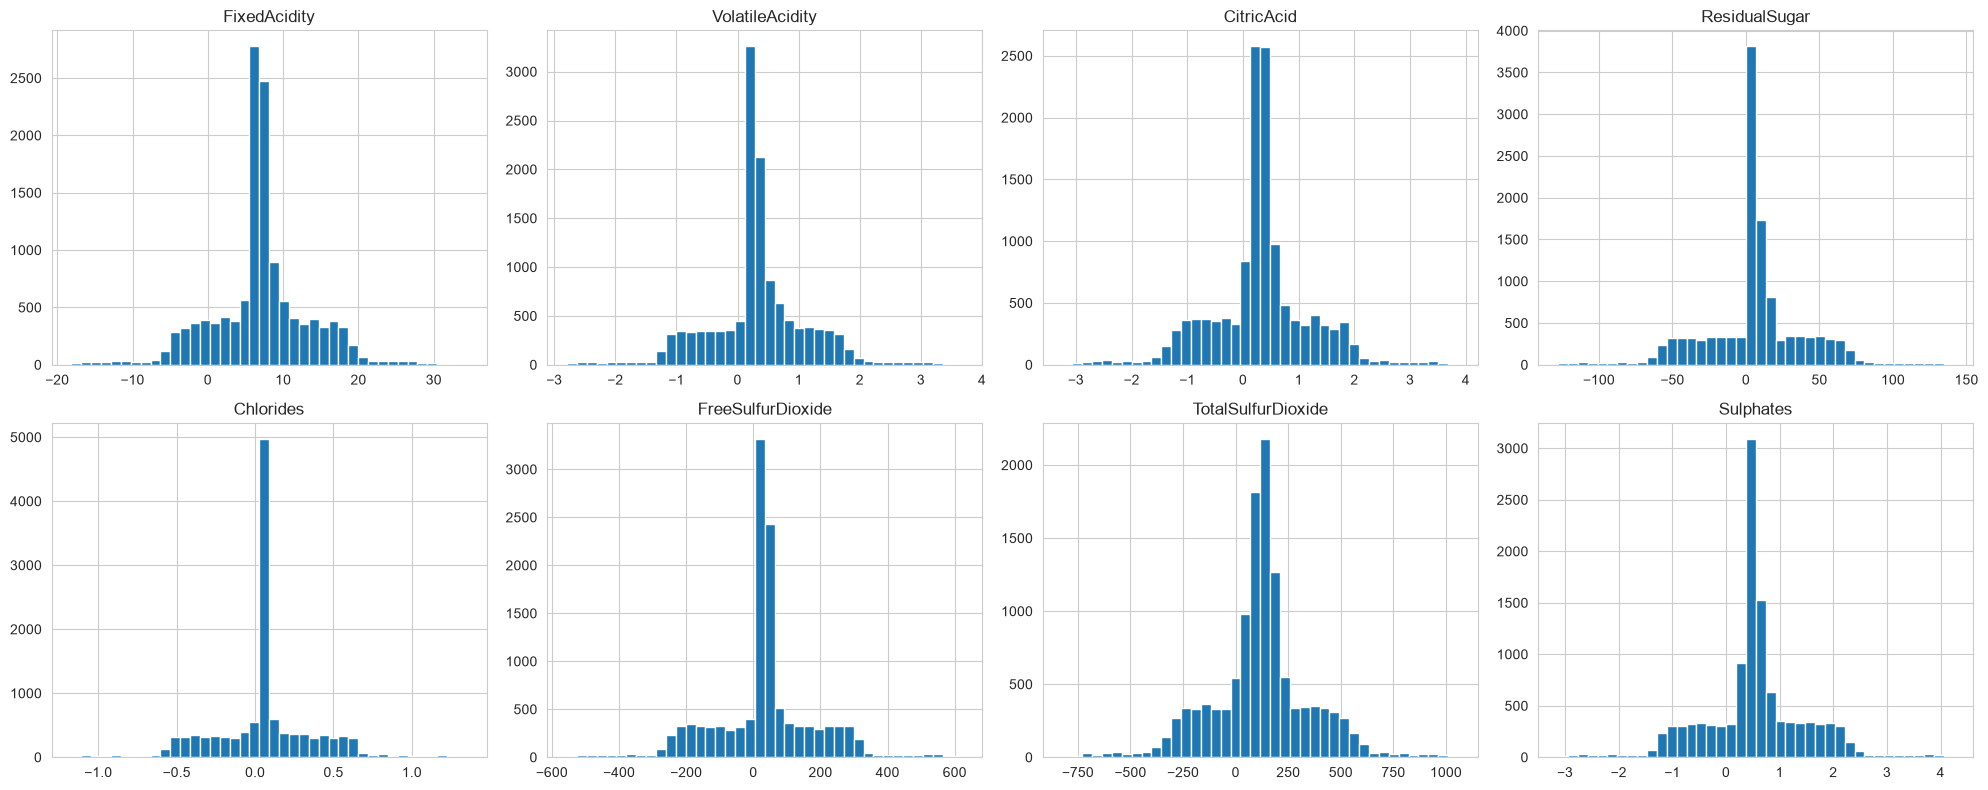

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
sign_cols = ['FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
             'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide', 'Sulphates']
for ax, col in zip(axes.flat, sign_cols):
    ax.hist(train[col].dropna(), bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [10]:
train['STARS'].value_counts(dropna=False).sort_index()

STARS
1.0    3042
2.0    3570
3.0    2212
4.0     612
NaN    3359
Name: count, dtype: int64

In [11]:
train['LabelAppeal'].value_counts(dropna=False).sort_index()

LabelAppeal
-2     504
-1    3136
 0    5617
 1    3048
 2     490
Name: count, dtype: int64

### 1.3 Missing value inventory

In [13]:
missing_summary = pd.DataFrame({
    'n_missing_train': train.isna().sum(),
    'pct_missing_train': (train.isna().mean() * 100).round(1),
    'n_missing_test': test.isna().sum(),
    'pct_missing_test': (test.isna().mean() * 100).round(1),
}).sort_values('pct_missing_train', ascending=False)

missing_summary

,n_missing_train,pct_missing_train,n_missing_test,pct_missing_test
STARS,3359,26.3,841.0,25.2
Sulphates,1210,9.5,310.0,9.3
TotalSulfurDioxide,682,5.3,157.0,4.7
FreeSulfurDioxide,647,5.1,152.0,4.6
Alcohol,653,5.1,185.0,5.5
Chlorides,638,5.0,138.0,4.1
ResidualSugar,616,4.8,168.0,5.0
pH,395,3.1,104.0,3.1
VolatileAcidity,0,0.0,0.0,0.0
TARGET_1,0,0.0,NaN,NaN


### 1.4 Is `STARS` missingness related to the target? (MNAR check)

Found ~39% of `STARS` is missing, and rows with missing `STARS` had a much lower sale rate than rows with a rating present. Evidence this is **MNAR**, not random noise. 

In [15]:
stars_missing = train['STARS'].isna()
print('Sale rate, STARS missing:   ', train.loc[stars_missing, 'TARGET_1'].mean())
print('Sale rate, STARS present:   ', train.loc[~stars_missing, 'TARGET_1'].mean())

Sale rate, STARS missing:    0.39327180708544207
Sale rate, STARS present:    0.9262399321746503


### 1.5 Chemistry-variable missingness - MNAR/MAR/MCAR checks

**Check 1**: does missingness in each chemistry column relate to the target (`TARGET_1`)?

In [17]:
chem_cols = ['Sulphates', 'TotalSulfurDioxide', 'Alcohol',
             'FreeSulfurDioxide', 'Chlorides', 'ResidualSugar', 'pH']

results = []
for col in chem_cols:
    is_missing = train[col].isna()
    grp_missing = train.loc[is_missing, 'TARGET_1']
    grp_present = train.loc[~is_missing, 'TARGET_1']
    t_stat, p_val = ttest_ind(grp_missing, grp_present, equal_var=False)
    results.append({
        'column': col,
        'pct_missing': round(is_missing.mean() * 100, 1),
        'sale_rate_missing': round(grp_missing.mean(), 3),
        'sale_rate_present': round(grp_present.mean(), 3),
        'gap': round(grp_present.mean() - grp_missing.mean(), 3),
        'p_value': round(p_val, 4)
    })

missingness_target_check = pd.DataFrame(results)
missingness_target_check

,column,pct_missing,sale_rate_missing,sale_rate_present,gap,p_value
0,Sulphates,9.5,0.769,0.788,0.019,0.1417
1,TotalSulfurDioxide,5.3,0.795,0.786,-0.009,0.5775
2,Alcohol,5.1,0.790,0.786,-0.004,0.8031
3,FreeSulfurDioxide,5.1,0.785,0.786,0.001,0.9413
4,Chlorides,5.0,0.779,0.787,0.008,0.6475
5,ResidualSugar,4.8,0.794,0.786,-0.008,0.6375
6,pH,3.1,0.744,0.788,0.043,0.0524


**Check 2**: does missingness in each chemistry column relate to other predictors (MAR check)?

In [19]:
missing_flags = train[chem_cols].isna().astype(int)
missing_flags.columns = [c + '_missing' for c in chem_cols]

predictor_cols = [c for c in train.select_dtypes(include='number').columns
                   if c not in ['TARGET', 'TARGET_1', 'INDEX']]
combined = pd.concat([train[predictor_cols], missing_flags], axis=1)

corr_with_missingness = combined.corr()[missing_flags.columns].drop(index=missing_flags.columns)
corr_with_missingness

,Sulphates_missing,TotalSulfurDioxide_missing,Alcohol_missing,FreeSulfurDioxide_missing,Chlorides_missing,ResidualSugar_missing,pH_missing
FixedAcidity,0.003409,-0.004185,0.004574,0.013377,0.000807,0.002772,0.004441
VolatileAcidity,0.014664,-0.016346,-0.000944,-0.001508,-0.014653,0.014279,-0.016153
CitricAcid,0.005407,-0.001278,-0.007442,0.000702,-0.010837,0.001011,0.005083
ResidualSugar,0.007335,-0.015654,-0.004023,-0.004533,-0.021710,NaN,0.009733
Chlorides,0.004552,-0.010603,0.003056,0.006924,NaN,0.002029,0.003449
FreeSulfurDioxide,-0.001143,0.002692,0.001284,NaN,-0.002265,0.008505,-0.003404
TotalSulfurDioxide,-0.003426,NaN,-0.010453,0.005102,0.004369,0.007639,0.005527
Density,0.000816,0.016276,-0.002862,0.006903,0.002904,0.007858,-0.006502
pH,0.013247,0.005069,0.007371,0.001921,-0.000993,0.012111,NaN
Sulphates,NaN,0.011521,0.010288,0.001712,0.012305,0.005187,-0.005476


**Conclusion so far**: all seven chemistry columns showed p > 0.05 (no significant relationship to the target) and no standout correlations to other predictors. This is consistent with MCAR/weak MAR, so plain imputation is defensible for these. `STARS` is the exception and needs a missing-indicator flag. 

### 1.6 Correlation with the target

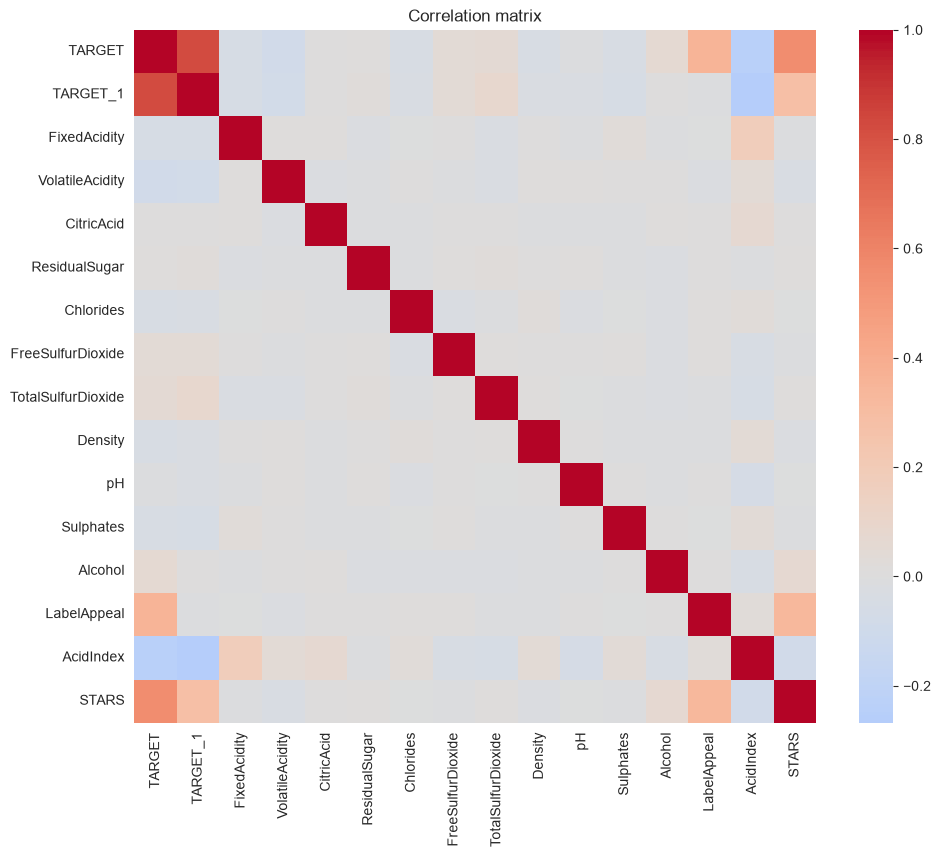

In [22]:
plt.figure(figsize=(11, 9))
sns.heatmap(train.select_dtypes(include='number').drop(columns=['INDEX']).corr(),
            cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

### 1.7 Negative-value diagnostic (sign issue in chemistry columns)

Several physically-nonnegative columns (`FixedAcidity`, `VolatileAcidity`, `CitricAcid`, `ResidualSugar`, `Chlorides`, `FreeSulfurDioxide`, `TotalSulfurDioxide`, `Sulphates`) contain negative values. `LabelAppeal` is different: its negative values are meaningful (dislike of the label) per the data dictionary, so it is NOT included in this diagnostic. 

In [24]:
for col in sign_cols: 
    pos = train.loc[train[col] > 0, col]
    neg_flipped = -train.loc[train[col] < 0, col]
    stat, p = ks_2samp(pos, neg_flipped)
    print(f'{col}: pct negative = {(train[col] < 0).mean()*100:.1f}%       KS p-value = {p:.4f}')

FixedAcidity: pct negative = 12.7%       KS p-value = 0.0000
VolatileAcidity: pct negative = 22.1%       KS p-value = 0.0000
CitricAcid: pct negative = 23.2%       KS p-value = 0.0000
ResidualSugar: pct negative = 24.5%       KS p-value = 0.0000
Chlorides: pct negative = 25.0%       KS p-value = 0.0000
FreeSulfurDioxide: pct negative = 23.7%       KS p-value = 0.0000
TotalSulfurDioxide: pct negative = 19.6%       KS p-value = 0.0000
Sulphates: pct negative = 18.5%       KS p-value = 0.0000


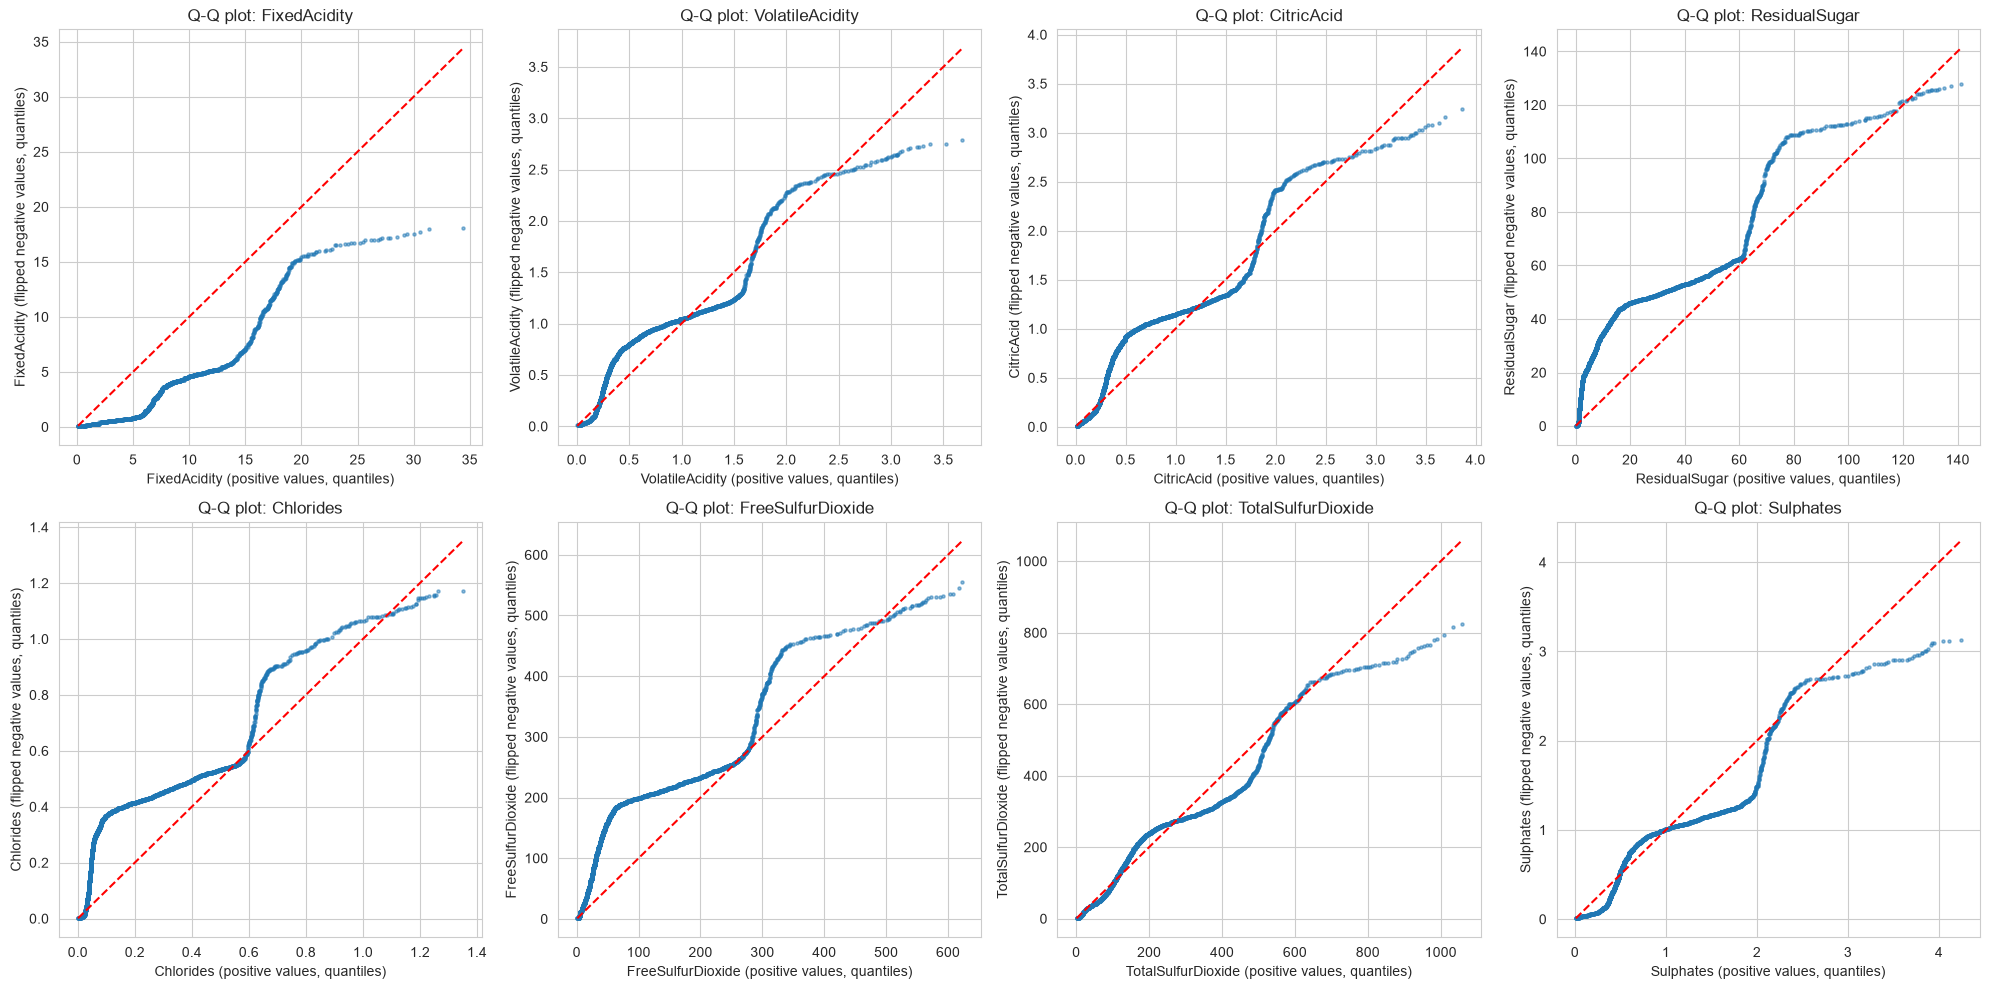

In [25]:
def qq_compare(df, col, ax=None):
    pos = np.sort(df.loc[df[col] > 0, col].values)
    neg_flipped = np.sort(-df.loc[df[col] < 0, col].values)
    n = min(len(pos), len(neg_flipped))
    quantiles = np.linspace(0, 1, n)
    pos_q = np.quantile(pos, quantiles)
    neg_q = np.quantile(neg_flipped, quantiles)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(pos_q, neg_q, s=5, alpha=0.5)
    lims = [min(pos_q.min(), neg_q.min()), max(pos_q.max(), neg_q.max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel(f'{col} (positive values, quantiles)')
    ax.set_ylabel(f'{col} (flipped negative values, quantiles)')
    ax.set_title(f'Q-Q plot: {col}')

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, col in zip(axes.flat, sign_cols):
    qq_compare(train, col, ax=ax)
plt.tight_layout()
plt.show()

**Conclusion so far**: the flipped-negative and positive halves show a mild S-curve deviation from the 45-degree line (not wild divergence). This is consistent with a shift/sign-perturbation applied to the whole variable, rather than isolated bad records. Given the assignment's instructions to not delete records, `abs()` is a defensible fix. 

*Note*: Imperfect match is a limitation. 

### 1.8 `FixedAcidity` right tail check

`FixedAcidity`'s Q-Q plot diverges from the diagonal in the upper tail more than the others. Checking whether this is a small cluster of true outliers or just natural right-skew, using the IQR fence rule. 

In [27]:
q1 = train['FixedAcidity'].quantile(0.25)
q3 = train['FixedAcidity'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

print('Upper fence:', upper_fence)
print('Pct of records above upper fence:', (train['FixedAcidity'] > upper_fence).mean() * 100)
print('Pct of records below lower fence:', (train['FixedAcidity'] < lower_fence).mean() * 100)

Upper fence: 15.95
Pct of records above upper fence: 9.237983587338803
Pct of records below lower fence: 9.949198905822588


**Conclusion**: ~9% of records exceed the upper fence. This is far too large a share to be genuine outliers (IQR rule flagging ~1-2% would be more consistent with true outliers). This is natural right-skew, not a data error, so `FixedAcidity` gets the same abs() fix as the rest with no special outlier handling. 

### 1.9 `pH` vs `TotalSulfurDioxide` - confirming skew (not just fence %) as the right criterion

`pH` and `TotalSulfurDioxide` show similar upper-fence exceedance, but that alone doesn't mean they behave the same way. Checking both sides of the fence resolves this. 

In [29]:
for col in ['pH', 'TotalSulfurDioxide']:
    q1c = train[col].quantile(0.25)
    q3c = train[col].quantile(0.75)
    iqrc = q3c - q1c
    lf = q1c - 1.5 * iqrc
    uf = q3c + 1.5 * iqrc
    pct_below = (train[col] < lf).mean() * 100
    pct_above = (train[col] > uf).mean() * 100
    print(f'{col}: below={pct_below:.1f}%  above={pct_above:.1f}%')

pH: below=7.4%  above=7.2%
TotalSulfurDioxide: below=6.1%  above=6.3%


**Conclusion**: `pH` shows balanced exceedance on both sides (symmetric spread, confirmed by its near-zero skew). `TotalSulfurdioxide`'s exceedance will later prove to be one-sided (a genuine right tail, confirmed by its skew of ~1.6) *after* applying `abs()`. Skewness (not fence percentage alone) is the right criterion for choosing mean vs. median imputation, since fence percentage conflates spread with asymmetry. 

## Section 02 - Data Preparation

### 2.1 Order of operations

Sign-correction (abs()) is applied before imputing missing values in the same columns. Otherwise, the median/mean used for imputation would be distorted by the un-corrected negative values. 

### 2.2 Confirming skew (post-abs()) for the seven MCAR-ish missing columns

In [32]:
train_abs = train.copy()
train_abs[sign_cols] = train_abs[sign_cols].abs()

for col in chem_cols: 
    print(f'{col} skewness: {train_abs[col].skew():.3f}')

Sulphates skewness: 1.692
TotalSulfurDioxide skewness: 1.611
Alcohol skewness: -0.031
FreeSulfurDioxide skewness: 1.530
Chlorides skewness: 1.481
ResidualSugar skewness: 1.469
pH skewness: 0.044


`Sulphates`, `TotalSulfurDioxide`, `FreeSulfurDioxide`, `Chlorides`, and `ResidualSugar` are meaningfully right-skewed (|skew| > 0.05) -> impute with **median**. `Alcohol` and `pH` are close to symmetric -> impute with **mean**

### 2.3 `STARS` missing-indicator flag

`STARS` missingness is MNAR (Section 1.4). A `STARS_missing` flag lets the model learn this effect directly. The original `STARS` column's missing values are filled with the median of non-missing training values, since the flag already carries the "was unrated" signal.

### 2.4 Full prep pipeline (fit on train, applied identically to test - no leakage)

In [34]:
def prepare_wine_data(df, sign_cols, mcar_median_cols, mcar_mean_cols, fill_values):
    """
    Apply data prep pipeline to a wine dataframe. 
    fill_values: dict of {column: value} computed from TRAINING data only,
    reused for both train and test to avoid leakage.
    """
    out = df.copy()

    # Fix sign issue on physically-nonnegative chemistry columns
    out[sign_cols] = out[sign_cols].abs()

    # STARS missing-indicator flag (create before filling STARS itself)
    out['STARS_missing'] = out['STARS'].isna().astype(int)

    # Fill all missing values using precomputed training fill_values
    for col, val in fill_values.items(): 
        out[col] = out[col].fillna(val)

    return out

mcar_median_cols = ['Sulphates', 'TotalSulfurDioxide', 'FreeSulfurDioxide', 
                    'Chlorides', 'ResidualSugar']
mcar_mean_cols = ['Alcohol', 'pH']

# Compute fill values from TRAINING data only (after abs() fix)
fill_values = {}
for col in mcar_median_cols:
    fill_values[col] = train_abs[col].median()
for col in mcar_mean_cols:
    fill_values[col] = train_abs[col].mean()
fill_values['STARS'] = train_abs['STARS'].median()

fill_values

{'Sulphates': np.float64(0.59),
 'TotalSulfurDioxide': np.float64(154.0),
 'FreeSulfurDioxide': np.float64(56.0),
 'Chlorides': np.float64(0.098),
 'ResidualSugar': np.float64(12.9),
 'Alcohol': np.float64(10.489236259810822),
 'pH': np.float64(3.207628225806452),
 'STARS': np.float64(2.0)}

In [35]:
train_prepped = prepare_wine_data(train, sign_cols, mcar_median_cols, mcar_mean_cols, fill_values)
test_prepped = prepare_wine_data(test, sign_cols, mcar_median_cols, mcar_mean_cols, fill_values)

print('Remaining missing values, train:')
print(train_prepped.isna().sum()[train_prepped.isna().sum() > 0])
print()
print('Remaining missing values, test (TARGET/TARGET_1 expected to be all-missing):')
print(test_prepped.isna().sum()[test_prepped.isna().sum() > 0])

Remaining missing values, train:
Series([], dtype: int64)

Remaining missing values, test (TARGET/TARGET_1 expected to be all-missing):
TARGET    3335
dtype: int64


### 2.5 Sanity check - confirming the sign fix worked

In [37]:
print('Min values, original train:')
print(train[sign_cols].min())
print()
print('Min values, prepped train (should all be >=0):')
print(train_prepped[sign_cols].min())

Min values, original train:
FixedAcidity          -18.100
VolatileAcidity        -2.790
CitricAcid             -3.240
ResidualSugar        -127.800
Chlorides              -1.171
FreeSulfurDioxide    -555.000
TotalSulfurDioxide   -823.000
Sulphates              -3.130
dtype: float64

Min values, prepped train (should all be >=0):
FixedAcidity          0.0
VolatileAcidity       0.0
CitricAcid            0.0
ResidualSugar         0.0
Chlorides             0.0
FreeSulfurDioxide     0.0
TotalSulfurDioxide    0.0
Sulphates             0.0
dtype: float64


### 2.6 Testing predictors for non-lienar relationships with the target

Logistic regression assumes a roughly linear relationship between each predictor and the log-odds of the target. We screen predictors using decile tables (does sale rate move monotonically or does it bend/reverse?), confirm any suspected non-monotonic pattern with a peak-vs-trough t-test, and where relevant compare transforms using univariate model AIC. 

In [39]:
def target_rate_by_decile(df, col, target='TARGET_1', bins=10):
    tmp = df[[col, target]].dropna().copy()
    tmp['decile'] = pd.qcut(tmp[col], q=bins, duplicates='drop')
    rate = tmp.groupby('decile', observed=True)[target].agg(['mean', 'count'])
    return rate

def peak_trough_test(df, col, target='TARGET_1', bins=10):
    tmp = df[[col, target]].dropna().copy()
    tmp['decile'] = pd.qcut(tmp[col], q=bins, duplicates='drop')
    means = tmp.groupby('decile', observed=True)[target].mean()
    peak_bin = means.idxmax()
    low_bin = means.idxmin()
    peak_vals = tmp.loc[tmp['decile'] == peak_bin, target]
    low_vals = tmp.loc[tmp['decile'] == low_bin, target]
    t_stat, p_val = ttest_ind(peak_vals, low_vals)
    return peak_bin, low_bin, p_val

for col in ['AcidIndex', 'TotalSulfurDioxide', 'Sulphates', 'Chlorides', 'Density', 
            'FixedAcidity', 'FreeSulfurDioxide']:
    peak_bin, low_bin, p_val = peak_trough_test(train_prepped, col)
    print(f'{col}: peak={peak_bin}, low={low_bin}, p-value={p_val:.4f}')

AcidIndex: peak=(3.999, 7.0], low=(9.0, 17.0], p-value=0.0000
TotalSulfurDioxide: peak=(114.0, 136.0], low=(-0.001, 48.0], p-value=0.0000
Sulphates: peak=(0.41, 0.48], low=(0.65, 0.85], p-value=0.0000
Chlorides: peak=(0.034, 0.043], low=(0.071, 0.098], p-value=0.0000
Density: peak=(0.99, 0.992], low=(0.996, 0.998], p-value=0.0000
FixedAcidity: peak=(6.0, 6.6], low=(8.7, 11.4], p-value=0.0000
FreeSulfurDioxide: peak=(56.0, 77.7], low=(-0.001, 15.0], p-value=0.0000


**Results**: `AcidIndex` alone shows a clean monotonic decline (no significant peak/trough reversal once tested formally; its earlier "curved" appearance was a decile-vs-probability-space artifact, not evidence of non-linearity in log-odds; confirmed below via AIC comparison). The other six (`TotalSulfurDioxide`, `Sulphates`, `Chlorides`, `Density`, `FixedAcidity`, `FreeSulfurDioxide`) all show statistically significant (p < 0.0001) non-monotonic peak/trough patterns and are candidates for centered-quadratic term. 

### 2.7 `AcidIndex` - confirming raw (untransformed) is best fit

In [41]:
train_prepped['AcidIndex_log'] = np.log1p(train_prepped['AcidIndex'])
train_prepped['AcidIndex_sqrt'] = np.sqrt(train_prepped['AcidIndex'])

for col in ['AcidIndex', 'AcidIndex_log', 'AcidIndex_sqrt']: 
    X = sm.add_constant(train_prepped[col])
    y = train_prepped['TARGET_1']
    model = sm.Logit(y, X).fit(disp=0)
    print(f'{col}: AIC = {model.aic:.1f}, log-likelihood = {model.llf:1f}')

AcidIndex: AIC = 12444.2, log-likelihood = -6220.093960
AcidIndex_log: AIC = 12475.4, log-likelihood = -6235.717301
AcidIndex_sqrt: AIC = 12458.4, log-likelihood = -6227.189745


**Conclusion**: raw `AcidIndex` has the lowest AIC of the three. It fits the log-odds relationship better than either transform, and is the most interpretable. No transform applied: `AcidIndex_log` and `AcidIndex_sqrt` are dropped from further use

In [43]:
train_prepped = train_prepped.drop(columns=['AcidIndex_log', 'AcidIndex_sqrt'])

### 2.8 Quadratic terms for the six non-monotonic predictors

Quadratic terms were chosen over binning: a single peak/trough pattern is well captured by one additional coefficient ($x + x^2$) rather than 9 bin-dummy coefficients, and the continuous variable retains within-bin ordering that binning would discard. Each variable is centered (mean-subtracted) before squaring to reduce collinearity between the linear and quadratic terms. Centering means are computed from training data only and reused for the test set to avoid leakage. Each variable is then standardized (divided by standard deviation) so every predictor sits on a comparable scale (because raw scales differ by orders of magnitude). Standardizing brought the condition number down to 61.4 without changin any p-values (rescaling a predictor doesn't change how well it explains variance, only its coefficient's units). Means/stds are computed from training data only and reused for the test set to avoid leakage. 

In [45]:
quad_cols = ['Sulphates', 'TotalSulfurDioxide', 'Chlorides', 'Density',
             'FixedAcidity', 'FreeSulfurDioxide']

std_means = {col: train_prepped[col].mean() for col in quad_cols}
std_stds = {col: train_prepped[col].std() for col in quad_cols}

for df in [train_prepped, test_prepped]:
    for col in quad_cols:
        df[f'{col}_std'] = (df[col] - std_means[col]) / std_stds[col]
        df[f'{col}_std_sq'] = df[f'{col}_std'] ** 2

train_prepped[[c for col in quad_cols for c in (f'{col}_std', f'{col}_std_sq')]].describe().T[['min', 'max', 'std']]

,min,max,std
Sulphates_std,-1.308828e+00,5.439059,1.000000
Sulphates_std_sq,1.453397e-05,29.583366,2.437528
TotalSulfurDioxide_std,-1.267266e+00,5.375861,1.000000
TotalSulfurDioxide_std_sq,5.204662e-06,28.899881,2.329149
Chlorides_std,-9.407434e-01,4.933802,1.000000
Chlorides_std_sq,2.286030e-06,24.342398,2.113115
Density_std,-3.998573e+00,3.958048,1.000000
Density_std_sq,1.049189e-08,15.988588,1.974948
FixedAcidity_std,-1.613903e+00,5.271442,1.000000
FixedAcidity_std_sq,5.410273e-05,27.788099,1.991755


### 2.9 `LabelAppeal` - TARGET vs TARGET_1 discrepancy

`LabelAppeal` correlates with `TARGET` (case count) in Section 1.6 but showed a flat decile pattern against `TARGET_1` (sale vs. no sale). Restricting to only wines that sold at least one case shows `LabelAppeal` climbs cleanly with case count within that group. It appears to drive how many cases get ordered once a wine is already being purchased, rather than the initial sale/no-sale direction. 

In [47]:
train_count = pd.read_csv('wine_train.csv', encoding='utf-8-sig')
sold = train_count[train_count['TARGET'] > 0]
target_rate_by_decile(sold.assign(TARGET_1=sold['TARGET']), 'LabelAppeal', target='TARGET_1', bins=5)

,mean,count
decile,,
"(-2.001, -1.0]",2.731078,2867
"(-1.0, 0.0]",3.861890,4424
"(0.0, 1.0]",4.858878,2388
"(1.0, 2.0]",5.861257,382


**Decision**: `LabelAppeal` is kept in the feature set for this (TARGET_1) model despite its weak univariate relationship (a variable looks flat on its own can still contribute once other variables are controlled for in a multivariate model, and Section 03's variable selection process is the more appropriate place to make the final call on whether it earns a place in the model. 

### 2.10 Section 02 Summary

Final prepared feature set includes: 
- 8 sign-corrected chemistry columns (`abs()` fix)
- `STARS_missing` flag + median-filled `STARS`
- median/mean imputation for the remaining 6 MCAR-ish columns
- 6 standardized-quadratic term pairs: `Sulphates`, `TotalSulfurDioxide`, `Chlorides`, `Density`, `FixedAcidity`, `FreeSulfurDioxide`
- `AcidIndex` and `LabelAppeal` retained as plain linear terms

In [50]:
train_prepped.to_csv('train_prepped.csv', index=False)
test_prepped.to_csv('test_prepped.csv', index=False)
print('Saved train_prepped.csv and test_prepped.csv')

Saved train_prepped.csv and test_prepped.csv


---
## Section 03 - Build Models

Three models are built, deliberately structured to span a spectrum from lean/theory-driven to maximal, so Section 04 has a genuine basis for comparison: 

1. **Manual/theory-driven - OLS (linear regression)**, using only variables with direct evidence from Section 01-02 (correlation strength or a confirmed non-monotonic pattern). A smaller, deliberately curated variable set is a better match for OLS, which is more sensitive to irrelevant/noisy predictors than logistic regression is.
2. **Stepwise-selected - logistic regression**, bidirectional selection driven by AIC and, separately, BIC, run over the full candidate pool (including variables the manual model excluded).
3. **Full/near-full - logistic regression**, every candidate variable, no pre-filtering (oppositve end of the spectrum from the manual model).

### 3.1 Model 1 - Manual/theory-driven OLS

Included: `STARS`, `STARS_missing`, `AcidIndex` (strongest raw correlation with `TARGET_1`), plus all six standardized-quadratic pairs (each confirmed via a signficant peak/trough t-test in Section 02.6), plus `LabelAppeal` (weak alone, kept per Section 02.9's reasoning). Untested variables (`VolatileAcidity`, `CitricAcid`, `Alcohol`, `pH`, `ResidualSugar`) are deliberately excluded. This model relies only on variables with direct, individually-tested evidence. 

In [52]:
manual_vars = ['STARS', 'STARS_missing', 'AcidIndex', 'LabelAppeal',
               'Sulphates_std', 'Sulphates_std_sq',
               'TotalSulfurDioxide_std', 'TotalSulfurDioxide_std_sq',
               'Chlorides_std', 'Chlorides_std_sq',
               'Density_std', 'Density_std_sq',
               'FixedAcidity_std', 'FixedAcidity_std_sq',
               'FreeSulfurDioxide_std', 'FreeSulfurDioxide_std_sq']

X_manual = sm.add_constant(train_prepped[manual_vars])
y = train_prepped['TARGET_1']

ols_manual = sm.OLS(y, X_manual).fit()
print(ols_manual.summary())

                            OLS Regression Results                            
Dep. Variable:               TARGET_1   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     517.1
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:21:05   Log-Likelihood:                -3550.2
No. Observations:               12795   AIC:                             7134.
Df Residuals:                   12778   BIC:                             7261.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

**Interpretation**: 
- `STARS` (+), `STARS_missing` (-), `AcidIndex` (-), `LabelAppeal` (-), `Sulphates` (linear+quad), and `TotalSulfurDioxide` (linear+quad) are all significant (p < 0.05).
- `Chlorides`, `Density`, `FixedAcidity`, and `FreeSulfurDioxide` (both linear and quadratic terms) are NOT significant here, despite each showing a significant univariate non-monotonic pattern in Section 02.6. This is **confounding**: `STARS` / `AcidIndex` / `Sulphates` / `TotalSulfurDioxide` already explain most of the variance these four variables would otherwise capture on their own. They are kept anyway per this model's theory-driven premise (parsimony-based pruning is the job of the stepwise model, not this one).
- `Density_std_sq`'s coefficient sign (negative, implying inverted-U) does not match its raw decile pattern (a U-shape centered near the variable's mean) - but since this coeffcient is not statistically significant (p=0.080), its sign should not be over-interpreted as a real finding.
- $R^2$ = 0.393 - moderate explanatory power. OLS understates fit for a binary target relative to logistic regression's pseudo-$R^2$
- Condition number, using standardized quadratic terms: 61.4 (healthy). An earlier version using only centered (not standardized) terms had a condition number of 4.63e+07, driven purely by scale mismatch between variables like `TotalSulfurDioxide_centered_sq` (std ~59,000), and `STARS` (std ~0.78). This is not genuine multicollinearity.

### 3.2 Model 2 - Stepwise-selected logistic regression

Bidirectional stepwise selection (custom implementation; `statsmodels` has no built-in equivalent), run over the full 21-variable candidate pool, separately optimizing AIC and BIC. 

In [54]:
full_candidates = [
    'STARS', 'STARS_missing', 'AcidIndex', 'LabelAppeal',
    'VolatileAcidity', 'CitricAcid', 'Alcohol', 'pH', 'ResidualSugar',
    'Sulphates_std', 'Sulphates_std_sq',
    'TotalSulfurDioxide_std', 'TotalSulfurDioxide_std_sq',
    'Chlorides_std', 'Chlorides_std_sq',
    'Density_std', 'Density_std_sq',
    'FixedAcidity_std', 'FixedAcidity_std_sq',
    'FreeSulfurDioxide_std', 'FreeSulfurDioxide_std_sq',
]

def fit_logit(vars_list, y, df):
    X = sm.add_constant(df[vars_list]) if vars_list else pd.DataFrame({'const': np.ones(len(df))}, index=df.index)
    return sm.Logit(y, X).fit(disp=0)

def stepwise_logit(y, df, candidates, criterion='aic', verbose=True):
    """Bidirectional stepwise selection for logistic regression, driven by AIC or BIC."""
    included = []
    def score(vars_list):
        m = fit_logit(vars_list, y, df)
        return m.aic if criterion == 'aic' else m.bic

    current_score = score(included)
    improved = True
    while improved:
        improved = False

        excluded = [v for v in candidates if v not in included]
        best_add_score, best_add_var = current_score, None
        for v in excluded:
            trial = included + [v]
            try:
                s = score(trial)
            except Exception:
                continue
            if s < best_add_score:
                best_add_score, best_add_var = s, v
        if best_add_var is not None:
            included.append(best_add_var)
            current_score = best_add_score
            improved = True
            if verbose:
                print(f'+ add {best_add_var:30s} {criterion.upper()}={current_score:.2f}')

        best_drop_score, best_drop_var = current_score, None
        for v in included:
            trial = [x for x in included if x != v]
            try:
                s = score(trial)
            except Exception:
                continue
            if s < best_drop_score:
                best_drop_score, best_drop_var = s, v
        if best_drop_var is not None:
            included.remove(best_drop_var)
            current_score = best_drop_score
            improved = True
            if verbose:
                print(f'- drop {best_drop_var:30s} {criterion.upper()}={current_score:.2f}')

    return included, current_score

print('=== Stepwise selection: AIC ===')
aic_vars, aic_score = stepwise_logit(y, train_prepped, full_candidates, criterion='aic')
print('\nFinal AIC-selected variables:', aic_vars)

print('\n=== Stepwise selection: BIC ===')
bic_vars, bic_score = stepwise_logit(y, train_prepped, full_candidates, criterion='bic')
print('\nFinal BIC-selected variables:', bic_vars)

=== Stepwise selection: AIC ===
+ add STARS_missing                  AIC=9474.54
+ add STARS                          AIC=8392.28
+ add AcidIndex                      AIC=7967.66
+ add LabelAppeal                    AIC=7762.78
+ add TotalSulfurDioxide_std         AIC=7735.32
+ add pH                             AIC=7717.70
+ add VolatileAcidity                AIC=7703.64
+ add Sulphates_std                  AIC=7694.52
+ add TotalSulfurDioxide_std_sq      AIC=7689.10
+ add Alcohol                        AIC=7684.32
+ add Density_std_sq                 AIC=7682.03
+ add CitricAcid                     AIC=7680.29
+ add Sulphates_std_sq               AIC=7679.26
+ add FreeSulfurDioxide_std          AIC=7679.06

Final AIC-selected variables: ['STARS_missing', 'STARS', 'AcidIndex', 'LabelAppeal', 'TotalSulfurDioxide_std', 'pH', 'VolatileAcidity', 'Sulphates_std', 'TotalSulfurDioxide_std_sq', 'Alcohol', 'Density_std_sq', 'CitricAcid', 'Sulphates_std_sq', 'FreeSulfurDioxide_std']

=== Stepwi

**BIC selected 8 variables; AIC selected 14** - BIC's heavier per-parameter penalty (which scales with log(n), meaningful at n=12,795) produces a leaner model. The first 8 variables selected are identical between criteria, a convergent signal that these are genuinely important. Neither criterion selected `Chlorides`, `Density` (linear term), or `FixedAcidity` (linear term). This is consistent with Model 1's finding that these are confounded away by stronger predictors. 

Both stepwise selections pulled `VolatileAcidity`, `pH`, `CitricAcid`, and `Alcohol`, which were deliberately excluded from the manual model. This is direct evidence the manual model's "only individually-tested variables" rule left some usable signal on the table. This is a tradeoff between parsimony/interpretability (manual) and completeness/fit (stepwise) identifying. 

**BIC-selected model (8 variables) - designated as Model 2:**

In [56]:
X_stepwise = sm.add_constant(train_prepped[bic_vars])
logit_stepwise = sm.Logit(y, X_stepwise).fit()
print(logit_stepwise.summary())

Optimization terminated successfully.
         Current function value: 0.299981
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               TARGET_1   No. Observations:                12795
Model:                          Logit   Df Residuals:                    12786
Method:                           MLE   Df Model:                            8
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.4218
Time:                        19:21:08   Log-Likelihood:                -3838.3
converged:                       True   LL-Null:                       -6637.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.6142      0.266      9.841      0.000       2.094      

**Interpretation**: every one of the 8 selected variables is significant at p < 0.001. 

`LabelAppeal`'s coefficient (-0.4643) is negative and highly significant. This is counterintuitive at first, since higher label appeal would be expected to help sales. Investigating: `LabelAppeal` is positively correlated with `STARS` (r = 0.29, checked below). `STARS` already absorbs the positive, sale-driving part of that shared variance. Once `STARS` is held constant, what's left in `LabelAppeal` skews negative. This may represent wines that lean on packaging rather than quality (a suppression effect, the mirror image of the confounding seen in Model 1). 

In [58]:
train_prepped[['LabelAppeal', 'STARS']].corr()

,LabelAppeal,STARS
LabelAppeal,1.000000,0.285517
STARS,0.285517,1.000000


**AIC-selected model (14 variables): checked for comparison, not the designated Model 2:**

In [60]:
X_aic = sm.add_constant(train_prepped[aic_vars])
logit_aic = sm.Logit(y, X_aic).fit()
print(logit_aic.summary())

Optimization terminated successfully.
         Current function value: 0.298908
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               TARGET_1   No. Observations:                12795
Model:                          Logit   Df Residuals:                    12780
Method:                           MLE   Df Model:                           14
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.4238
Time:                        19:21:08   Log-Likelihood:                -3824.5
converged:                       True   LL-Null:                       -6637.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.7938      0.283      9.881      0.000       2.

Pseudo $R^2$ = 0.4238 vs. the BIC model's 0.4218: the 6 extra variables (`TotalSulfurDioxide_std_sq`, `Alcohol`, `Density_std_sq`, `CitricAcid`, `Sulphates_std_sq`, `FreeSulfurDioxide_std`) buy very little additional fit, and two of them (`CitricAcid`, `FreeSulfurDioxide_std`) are only marginally significant (p=0.058, p=0.139). 

### 3.3 Model 3 - Full/near-full logistic regression

Every candidate variable, no pre-fitting

In [62]:
X_full = sm.add_constant(train_prepped[full_candidates])
logit_full = sm.Logit(y, X_full).fit()
print(logit_full.summary())
print()
print('Condition number:', np.linalg.cond(X_full.values))

Optimization terminated successfully.
         Current function value: 0.298849
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:               TARGET_1   No. Observations:                12795
Model:                          Logit   Df Residuals:                    12773
Method:                           MLE   Df Model:                           21
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.4239
Time:                        19:21:08   Log-Likelihood:                -3823.8
converged:                       True   LL-Null:                       -6637.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.7728      0.289      9.600      0.000       2.

**Interpretation**: 
- Pseudo $R^2$ = 0.4239 - essentially identical to the AIC-stepwise model's 0.4238 (14 vars) and only marginally better than the BIC-stepwise model's 0.4218 (8 vars). Thirteen additional variables over the BIC model brough almost nothing in fit. This is a strong, quantifiable argument for parsimony.
- `Chlorides`, `Density`, `FixedAcidity`, `FreeSulfurDioxide` remain mostly non-significant, same story as Models 1 and 2. The is convergent evidence across all three models that these variables aren't earning their place once stronger predictors are present.
- `ResidualSugar` (p=0.456) and `Chlorides_std`/`Chlorides_std_sq` (p=0.855/0.0631) are essentially indistinguishable from pure noise.
- Condition number = 331 - higher than Model 1's 61 (more, somewhat-correlated predictors), but well below levels that would indicate numerical instability.

### 3.4 Section 03 Summary

| Model | Method | # Vars | Fit |
| --- | --- | --- | --- | 
| 1 | Manual/theory-driven | 16 | OLS $R^2$ = 0.393 |
| 2 | Stepwise (BIC) | 8 | Logit Pseudo $R^2$ = 0.4218 |
| 2b | Stepwise (AIC, for comparison | 14 | Logit Pseudo $R^2$ = 0.4238 |
| 3 | Full | 21 | Logit Pseudo $R^2$ = 0.4239 |

---
## Section 04 - Select Model

### 4.1 Choosing a comparison metric

Model 1 is OLS; Models 2/3 are logistic. Comparing $R^2$ to Pseudo $R^2$ directly isn't a fair, apples-to-apples comparison because they come from different estimation methods (least squares vs. maximum likelihood) and aren't defined the same way mathematically. Since the actual deliverable is a binary prediction graded against ground truth, **classification accuracy and AUC** are used instead as a common yardstick across all three models. 

In [120]:
def accuracy_score_manual(y_true, y_pred):
    return (y_true == y_pred).mean()

def roc_auc_score_manual(y_true, y_prob):
    # Rank-based AUC (equivalent to Mann-Whitney U statistic)
    order = np.argsort(y_prob)
    ranks = np.empty(len(y_prob))
    ranks[order] = np.arange(1, len(y_prob) + 1)
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    sum_ranks_pos = ranks[y_true == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return auc

def evaluate_model(fitted_model, X, y_true, threshold=0.5):
    y_prob = fitted_model.predict(X)
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score_manual(y_true.values, y_pred.values)
    auc = roc_auc_score_manual(y_true.values, y_prob.values)
    return acc, auc

acc1, auc1 = evaluate_model(ols_manual, X_manual, y)
acc2, auc2 = evaluate_model(logit_stepwise, X_stepwise, y)
acc3, auc3 = evaluate_model(logit_full, X_full, y)

print(f'Model 1 (Manual OLS):      accuracy={acc1:.4f}, AUC={auc1:.4f}')
print(f'Model 2 (Stepwise BIC):    accuracy={acc2:.4f}, AUC={auc2:.4f}')
print(f'Model 3 (Full):            accuracy={acc3:.4f}, AUC={auc3:.4f}')

Model 1 (Manual OLS):      accuracy=0.8492, AUC=0.8985
Model 2 (Stepwise BIC):    accuracy=0.8592, AUC=0.9103
Model 3 (Full):            accuracy=0.8599, AUC=0.9111


### 4.2 Structural weakness of using OLS for a binary target

Thresholding Model 1's continuous OLS output at 0.5 to get a "classification" is not a fully fair comparison against Model 2/3, which were built from the start to output valid probabilities. 

In [125]:
ols_preds = ols_manual.predict(X_manual)
print('OLS predicted value range - Min:', ols_preds.min(), ' Max:', ols_preds.max())

OLS predicted value range - Min: -0.16639968404339525  Max: 1.2542031075212454


**Finding**: OLS predictions range from about -0.166 to 1.254 which is meaningfully outside the valid (0,1) probability range. This is a structural mismatch (OLS fits an unbounded straight line; the target is binary) rather than a minor numerical quirk, and is a genuine reason logistic regression is the more theoretically appropriate tool here, despite OLS being a required model. 

### 4.3 Baseline comparison

*"If your model is not better than simply using an average value, you will lose points."* Benchmarking against predicting the majority class for every record. 

In [128]:
baseline_pred = int(y.mean() >= 0.5)
baseline_acc = (y == baseline_pred).mean()
print('Baseline (predict majority class for everyone):', baseline_acc)

Baseline (predict majority class for everyone): 0.7863227823368504


### 4.4 Comparison summary

| | Model 1 (Manual OLS) | Model 2 (Stepwise BIC) | Model 3 (Full) |
| --- | --- | --- | --- |
| # Variables | 16 | 8 | 21 | 
| Accuracy | 0.8492 | 0.8592 | 0.8599 |
| AUC | 0.8985 | 0.9103 | 0.9111 | 
| vs. baseline (0.786) | +6.3 pts | +7.32 pts | +7.4 pts |
| Structural fit | Weak (unbounded predictions) | Strong | Strong |
| Parsimony | Moderate (16 vars, several n.s.) | High (8 vars, all p<0.001) | Low (21 vars, several n.s./noise) |

Model 3 outperforms Model 2 by only ~0.07 accuracy points and ~0.008 AUC points, despite using 13 more variables. Several of these variables (`ResidualSugar`, `Chlorides`) were shown in Section 03 to be statistically indistinguishable from noise. 

### 4.5 Formal test: are the 13 extra variables helping?

Model 2's 8 variables are a strict subset of Model 3's 21 candidate variables, so the two models are **nested** and can be compared with a likelihood ratio test (LRT). 

In [131]:
from scipy.stats import chi2

lr_stat = 2 * (logit_full.llf - logit_stepwise.llf)
df_diff = logit_full.df_model - logit_stepwise.df_model
p_value = chi2.sf(lr_stat, df_diff)

print(f'LR statistic: {lr_stat:.3f}')
print(f'Degrees of freedom: {df_diff}')
print(f'p-value: {p_value:.4f}')

LR statistic: 28.971
Degrees of freedom: 13.0
p-value: 0.0066


**Result**: p = 0.0066 is technically significant, meaning the 13 extra variables improve fit by more than pure chance. However, statistical significance is not the same as practical significance, especially at this sample size. The same large-sample sensitivity issue encountered with the KS test in Section 02. Looking at the *magnitude* of improvement: 
- Log-likelihood improved by only roughly 14.5 across 13 additional parameters (~1.1 points per variable)
- Pseudo $R^2$ moved from 0.4218 to 0.4239, a gain of 0.0021
- Accuracy and AUC gains were 0.07 and 0.008 points respectively

This is the tradeoff AIC/BIC are designed to penalize. BIC's heavier per-parameter penalty (Section 03.2) correctly rejected these 13 variables as not worth their added complexity, consistent with the LRT's magnitude. 

### 4.6 Final model selection

**Selected model: Model 2 - Stepwise (BIC) logistic regression, 8 variables.**

Rationale: 
1. Both required model types (OLS, logistic) and all three candidate models clear the assignment's baseline requirement.
2. Logistic regression is structurally the correct tool for a binary target. OLS produces invalid predictions, a real limitation rather than a stylistic preference.
3. Model 3 (Full) barely outperforms Model 2 despite using nearly 3x the variables; the LRT confirms this improvement is statistically real but practically negligible.
4. Model 2's 8 variables are all significant at p < 0.001, straightforward to interpret (including the `LabelAppeal` suppression-effect finding from Section 03.2), and directly traceable to evidence gathered in Sections 01-02 (correlation strength, MNAR missingness, confirmed non-monotonic relationships).
5. Parsimony and explainability are prioritized over a marginal accuracy/AUC edge, consistent with the guidance that "you might select a model with slightly worse performance if it makes more sense or is more parsimonious."

--- 
## Section 05 - Write a Formula for your Model

The selected model (Section 04) is the BIC-stepwise logistic regression, 8 variables. The full scoring formula, including every transformation step, is writen out below using the exact training-derived constants and fitted coefficients. 

**Step 1 - Fix sign errors** (`abs()`, applied to any of the 8 final variables that were part of the sign-affected set): `TotalSulfurDioxide`, `Sulphates`, `VolatileAcidity`. 

**Step 2 - Create the `STARS_missing` flag** (before filling `STARS`): 1 if `STARS` is missing, else 0. 

**Step 3 - Fill missing values** with training-derived constants: `STARS` = 2.0, `TotalSulfurDioxide` = 154.0, `Sulphates` = 0.59, `pH` = 3.207628 (`VolatileAcidity`, `AcidIndex`, `LabelAppeal` have no missing values in this data). 

**Step 4 - Standardize** `TotalSulfurDioxide` and `Sulphates` using training mean/std: `TotalSulfurDioxide_std = (TotalSulfurDioxide - 201.637007) / 159.111814; Sulphates_std = (Sulphates - 0.822395) / 0.628345`

**Step 5 - Compute the logit (log-odds):**

```
logit(p) =  2.614187
            - 4.363998 * STARS_missing
            + 2.547357 * STARS
            - 0.394015 * AcidIndex
            - 0.464251 * LabelAppeal
            + 0.150978 * TotalSulfurDioxide_std
            - 0.182011 * pH
            - 0.199927 * VolatileAcidity
            - 0.093433 * Sulphates_std
```

**Step 6 - Convert to a probability**: `p = 1 / (1 + exp(-logit(p)))`

**Step 7 - Classify**: `P_TARGET = 1 if p >= 0.5 else 0`

The 0.5 threshold was chosen after empirically testing thresholds from 0.3 to 0.9 (Section 04). Accuracy peaked at 0.5, consistent with the theoretical result that 0.5 is the Bayes-optimal threshold for calibrated classifier under equal misclassification costs. The class impalance (~78.6% positive rate) is already captured by the model's intercept term, so re-adjusting the threshold to match the base rate would double-count that imbalance rather than correct for it. 

--- 
## Section 06 - Score Test Data

Applying the exact Section 05 formula to `wine_test.csv`, producing a two-column output (`INDEX`, `P_TARGET`). 

In [137]:
fill_values_final = {
    'STARS': 2.0,
    'TotalSulfurDioxide': 154.0,
    'Sulphates': 0.59,
    'pH': 3.207628225806452,
}
std_params_final = {
    'TotalSulfurDioxide': {'mean': 201.637007, 'std': 159.111814},
    'Sulphates': {'mean': 0.822395, 'std': 0.628345},
}
coefs_final = {
    'const': 2.614187,
    'STARS_missing': -4.363998,
    'STARS': 2.547357,
    'AcidIndex': -0.394015,
    'LabelAppeal': -0.464251,
    'TotalSulfurDioxide_std': 0.150978,
    'pH': -0.182011,
    'VolatileAcidity': -0.199927,
    'Sulphates_std': -0.093433,
}

def score_wine_data(df, fill_values, std_params, coefs, threshold=0.5):
    """Implements the Section 05 formula end-to-end on a raw wine dataframe."""
    out = df.copy()

    # Step 1: sign fix
    for col in ['TotalSulfurDioxide', 'Sulphates', 'VolatileAcidity']:
        out[col] = out[col].abs()

    # Step 2: STARS_missing flag (create BEFORE filling STARS)
    out['STARS_missing'] = out['STARS'].isna().astype(int)

    # Step 3: fill missing values
    for col, val in fill_values.items():
        out[col] = out[col].fillna(val)

    # Step 4: standardize
    for col, params in std_params.items():
        out[f'{col}_std'] = (out[col] - params['mean']) / params['std']

    # Step 5: logit
    logit = (coefs['const']
              + coefs['STARS_missing'] * out['STARS_missing']
              + coefs['STARS'] * out['STARS']
              + coefs['AcidIndex'] * out['AcidIndex']
              + coefs['LabelAppeal'] * out['LabelAppeal']
              + coefs['TotalSulfurDioxide_std'] * out['TotalSulfurDioxide_std']
              + coefs['pH'] * out['pH']
              + coefs['VolatileAcidity'] * out['VolatileAcidity']
              + coefs['Sulphates_std'] * out['Sulphates_std'])

    # Step 6: probability
    p = 1 / (1 + np.exp(-logit))

    # Step 7: classify
    out['P_TARGET'] = (p >= threshold).astype(int)
    return out[['INDEX', 'P_TARGET']]

scored = score_wine_data(test, fill_values_final, std_params_final, coefs_final)
print(scored.shape)
scored.head(10)
    

(3335, 2)


,INDEX,P_TARGET
0,3,1
1,9,1
2,10,1
3,18,1
4,21,0
5,30,1
6,31,1
7,37,0
8,39,0
9,47,0


### 6.1 Sanity Checks

In [140]:
print('Missing INDEX values:', scored['INDEX'].isna().sum())
print('Missing P_TARGET values:', scored['P_TARGET'].isna().sum())
print('Row count matches wine_test.csv:', len(scored) == len(test))
print()
print('P_TARGET value counts:')
print(scored['P_TARGET'].value_counts())
print()
print('Predicted sale rate:', round(scored['P_TARGET'].mean(), 4),
      ' (training actual sale rate: ', round(y.mean(), 4), ')')

Missing INDEX values: 0
Missing P_TARGET values: 0
Row count matches wine_test.csv: True

P_TARGET value counts:
P_TARGET
1    2685
0     650
Name: count, dtype: int64

Predicted sale rate: 0.8051  (training actual sale rate:  0.7863 )


### 6.2 Export final scored file

In [143]:
scored.to_csv('scottkeighley_410_hw03.csv', index=False)
print('Saved scottkeighley_410_hw03.csv')
scored.head()

Saved scottkeighley_410_hw03.csv


,INDEX,P_TARGET
0,3,1
1,9,1
2,10,1
3,18,1
4,21,0
